# 06 - Feature Engineering

Các bài toán được phát biểu đều có thể quy về 1 dạng của bài toán predict price. Vì vậy, ta chỉ cần 1 kiểu feature engineering

# 1. Set Up

In [208]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import math

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "data" and PROJECT_ROOT.parent.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_PATH =  PROCESSED_DIR / "laptop_processed.csv"
DATA_PATH = PROJECT_ROOT / "data" / "intern" / "laptop_feature_selection_for_fe.csv"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing merged dataset: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Data shape: {df.shape}")

PROJECT_ROOT: y:\Python\Laptop-Price-Prediction
Data shape: (10080, 32)


# 2. Overview of the dataset

Kiểm tra lại dữ liệu trước khi feature engineering

In [209]:
print(df.columns.tolist())
display(df.dtypes.to_frame("dtype"))

['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_grouped', 'model_grouped', 'cpu_brand', 'cpu_tier', 'gpu_tier', 'storage_type_clean', 'condition_clean', 'warranty_status', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing', 'ram_suspicious', 'storage_suspicious', 'screen_suspicious', 'potential_dedicated_gpu', 'repair_mismatch', 'is_soft_duplicate_spec', 'target_price', 'log_target_price', 'source', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu']


,dtype
ram_gb,float64
storage_gb,float64
screen_size_inch,float64
brand_grouped,object
model_grouped,object
cpu_brand,object
cpu_tier,object
gpu_tier,object
storage_type_clean,object
condition_clean,object


In [210]:
# Chuyển đổi type cho chính xác
bool_cols = [
    'no_info_brand', # int64
    'no_info_model', # int64
    'no_info_cpu_brand', # int64
    'no_info_cpu_tier', # int64
    'no_info_gpu', # int64
    'model_is_rare' # object
]

for col in bool_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.lower()
                .map({
                    'true': True,
                    'false': False,
                    '1': True,
                    '0': False
                })
                .fillna(False)
                .astype(bool)
            )
        else:
            df[col] = df[col].fillna(0).astype(int).astype(bool)

In [211]:
# 1. Pop cột source ra khỏi df
source = df.pop("source")

# 2. Tách target
target = df[["target_price", "log_target_price"]].copy()

y_price = df["target_price"].copy()
y_log_price = df["log_target_price"].copy()

# 3. Tạo X bằng cách bỏ target khỏi df
X = df.drop(columns=["target_price", "log_target_price"])

# 4. Chia nhóm feature theo kiểu dữ liệu
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

boolean_features = X.select_dtypes(include=["bool"]).columns.tolist()

# 5. In kết quả kiểm tra
print("Source shape:", source.shape)

print("Target columns:", target.columns.tolist())
print("y_price:", y_price.name)
print("y_log_price:", y_log_price.name)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Boolean features:", boolean_features)

print("Số numeric:", len(numeric_features))
print("Số categorical:", len(categorical_features))
print("Số boolean:", len(boolean_features))

Source shape: (10080,)
Target columns: ['target_price', 'log_target_price']
y_price: target_price
y_log_price: log_target_price
Numeric features: ['ram_gb', 'storage_gb', 'screen_size_inch']
Categorical features: ['brand_grouped', 'model_grouped', 'cpu_brand', 'cpu_tier', 'gpu_tier', 'storage_type_clean', 'condition_clean', 'warranty_status']
Boolean features: ['brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing', 'ram_suspicious', 'storage_suspicious', 'screen_suspicious', 'potential_dedicated_gpu', 'repair_mismatch', 'is_soft_duplicate_spec', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu']
Số numeric: 3
Số categorical: 8
Số boolean: 18


# Type of features
Chúng ta sẽ giữ cả 2 target trong data để kiểm tra cả 2, vì theo EDA trước đó cho thấy giá gốc cũng quan trọng dù cho distribution không có phân phối chuẩn

Các cột numeric bao gồm `ram_gb`, `storage_gb`, `screen_size_inch`, đây là các tính hiệu quan trọng. Đồng thời trong dataset hiện tại cũng sẽ khảo sát các giá trị được categorical hóa của các feature này để kiểm tra xem cách nào mang lại hiệu quả tốt hơn.

Các feature mang tính categorical có thể được feature hóa theo hướng One-hot hoặc Ordinary tùy theo tính hiệu của chúng

Các feature `boolean` chủ yếu gồm các tính hiệu missing hay no-infomation và các tính hiệu cảnh báo nói chung.

In [212]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

# Chỉ hiện các cột có missing_count > 0
missing_summary = missing_summary[missing_summary["missing_count"] > 0]

display(missing_summary)

Shape: (10080, 31)
Duplicate rows: 274


,missing_count,missing_percent
screen_size_inch,988,9.802
storage_gb,577,5.724
ram_gb,181,1.796


Các feature này sẽ được fill bằng Orther trogn quá tình feature engineering

In [213]:
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

bool_summary = pd.DataFrame({
    "true_count": df[bool_cols].sum(),
    "true_percent": df[bool_cols].mean() * 100
}).sort_values("true_percent", ascending=False)

display(bool_summary)

,true_count,true_percent
no_info_model,7355,72.966
is_soft_duplicate_spec,2514,24.940
no_info_gpu,2384,23.651
model_is_rare,2147,21.300
gpu_missing,1514,15.020
screen_missing,1027,10.188
no_info_cpu_tier,771,7.649
storage_missing,613,6.081
no_info_brand,391,3.879
no_info_cpu_brand,344,3.413


Ta loại `is_soft_duplicate_spec` và xóa đi các dòng duplicate, đồng thời các cột constant sẽ đucợ xóa đi. Các feature có true percent nhhor hơn 1% được giữ lại và có thể bị xóa đi trong qua trình evaluation

In [214]:
# Xóa các dòng soft duplicate trước
df = df[df["is_soft_duplicate_spec"] == False].copy()

# Sau đó bỏ luôn cột đánh dấu duplicate
df = df.drop(columns=["is_soft_duplicate_spec"])

# Xóa các cột constant
df = df.drop(columns=["storage_suspicious"])
df = df.drop(columns=["screen_suspicious"])

In [215]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

cardinality = pd.DataFrame({
    "n_unique": df[cat_cols].nunique(),
    "top_value": df[cat_cols].mode().iloc[0],
    "top_freq": [df[col].value_counts(dropna=False).iloc[0] for col in cat_cols]
}).sort_values("n_unique", ascending=False)

display(cardinality)

,n_unique,top_value,top_freq
model_grouped,32,Other,4841
brand_grouped,13,Dell,2117
gpu_tier,11,Integrated - Intel,2528
cpu_tier,9,Mid,2789
cpu_brand,6,Intel,5930
storage_type_clean,4,SSD,6513
condition_clean,4,Đã sử dụng (chưa sửa chữa),5456
warranty_status,4,Manufacturer,2871


In [216]:
print("Shape:", df.shape)

Shape: (7566, 28)


# 3. Check Feture Engineering - Boolean Feature

Chúng ta sẽ khảo sát các boolean feature về một số khía cạnh để kiểm tra độ ảnh hưởng của chúng đến target và đối với các feature khác.

Kiểm tra các feature boolean hiện tại

In [217]:
boolean_features = df.select_dtypes(include=["bool"]).columns.tolist()
print("Boolean features:", boolean_features)
print("Số boolean:", len(boolean_features))

Boolean features: ['brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing', 'ram_suspicious', 'potential_dedicated_gpu', 'repair_mismatch', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu']
Số boolean: 15


In [218]:
# Các cặp feature và cột no_info tương ứng
check_pairs = {
    "brand_grouped": "no_info_brand",
    "model_grouped": "no_info_model",
    "cpu_brand": "no_info_cpu_brand",
    "cpu_tier": "no_info_cpu_tier",
    "gpu_tier": "no_info_gpu",
}

# Các giá trị được xem là không có thông tin
no_info_values = ["other", "unknown", "missing", "orther"]

for feature_col, no_info_col in check_pairs.items():
    print(f"\n===== Kiểm tra {feature_col} -> {no_info_col} =====")

    # Chuẩn hóa text: bỏ khoảng trắng và chuyển về chữ thường
    feature_clean = df[feature_col].astype("string").str.strip().str.lower()

    # Điều kiện feature thuộc nhóm no_info
    condition_other = feature_clean.isin(no_info_values)

    # Điều kiện no_info phải bằng 1
    condition_no_info_true = df[no_info_col].eq(1)

    # Kiểm tra các dòng feature là Other/Unknown/Missing nhưng no_info không bằng 1
    wrong_rows = df[condition_other & ~condition_no_info_true]

    if wrong_rows.empty:
        print("Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1")
    else:
        print("Sai: có dòng Other/Unknown/Missing nhưng no_info != 1")
        print("Số dòng sai:", len(wrong_rows))
        display(wrong_rows[[feature_col, no_info_col]].head(20))


===== Kiểm tra brand_grouped -> no_info_brand =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra model_grouped -> no_info_model =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra cpu_brand -> no_info_cpu_brand =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra cpu_tier -> no_info_cpu_tier =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1

===== Kiểm tra gpu_tier -> no_info_gpu =====
Đúng: tất cả dòng Other/Unknown/Missing đều có no_info = 1


Các missing thuộc về categorical bị thay thế bởi nhóm `no_info_*`, ta xóa đi các cột đó

In [219]:
# Xóa các cột constant
df = df.drop(columns=["gpu_missing"])
df = df.drop(columns=["cpu_missing"])

In [220]:
missing_map = {
    "ram_gb": "ram_missing",
    "storage_gb": "storage_missing",
    "screen_size_inch": "screen_missing",
}

for col, missing_col in missing_map.items():
    df[missing_col] = df[col].isna()

for col, missing_col in missing_map.items():
    is_correct = (df[col].isna() == df[missing_col]).all()
    print(f"{col} - {missing_col}: {is_correct}")

ram_gb - ram_missing: True
storage_gb - storage_missing: True
screen_size_inch - screen_missing: True


Ta còn lại các feature sau `brand_is_rare`, `model_is_rare`, `ram_suspicious`, `potential_dedicated_gpu`, `repair_mismatch`

In [221]:
rare_brands = (
    df.loc[df["brand_is_rare"] == True, "brand_grouped"]
      .value_counts(dropna=False)
)

print(rare_brands)

rare_models = (
    df.loc[df["model_is_rare"] == True, "model_grouped"]
      .value_counts(dropna=False)
)

print(rare_models)

brand_grouped
Other    130
Name: count, dtype: int64
model_grouped
Other    2147
Name: count, dtype: int64


Kết quả hiện tại chưa tốt, bắt đầu config lại với threshold 1%

In [222]:
brand_threshold = 0.01
model_threshold = 0.01

brand_freq = df["brand_grouped"].value_counts(normalize=True, dropna=False)
model_freq = df["model_grouped"].value_counts(normalize=True, dropna=False)

df["brand_is_rare"] = (
    df["brand_grouped"].map(brand_freq) < brand_threshold
).astype(int)

df["model_is_rare"] = (
    df["model_grouped"].map(model_freq) < model_threshold
).astype(int)

In [223]:
rare_brands = (
    df.loc[df["brand_is_rare"].eq(1), "brand_grouped"]
      .value_counts(dropna=False)
      .to_frame("count")
)

rare_brands["percent"] = rare_brands["count"] / len(df) * 100
rare_brands["percent"] = rare_brands["percent"].round(3)

rare_models = (
    df.loc[df["model_is_rare"].eq(1), "model_grouped"]
      .value_counts(dropna=False)
      .to_frame("count")
)

rare_models["percent"] = rare_models["count"] / len(df) * 100
rare_models["percent"] = rare_models["percent"].round(3)

print("Rare brands:")
print(rare_brands)

print("\nRare models:")
print(rare_models)

Rare brands:
               count  percent
brand_grouped                
Sony              30    0.397
Toshiba           26    0.344
LG                25    0.330
Gigabyte          14    0.185

Rare models:
                    count  percent
model_grouped                     
Vostro                 75    0.991
ThinkPad X1 Carbon     65    0.859
Legion 5               59    0.780
Latitude 14 7000       58    0.767
Macbook air m4         51    0.674
Latitude E Series      49    0.648
TUF Gaming F15         42    0.555
XPS 13                 42    0.555
TUF Gaming             42    0.555
MacBook Air M2         41    0.542
Pavilion 15            40    0.529
Vivobook 15            40    0.529
Gaming Thin GF         40    0.529
Elitebook 800          37    0.489
X Series               36    0.476
IdeaPad                33    0.436
MacBook Pro M2         30    0.397
Aspire                 30    0.397
ROG Strix              29    0.383
Legion                 26    0.344


In [224]:
# Group các brand/model rare thành Other trước khi one-hot
df["brand_grouped"] = df["brand_grouped"].where(
    df["brand_is_rare"].eq(0),
    "Other"
)

df["model_grouped"] = df["model_grouped"].where(
    df["model_is_rare"].eq(0),
    "Other"
)

In [225]:
ram_sus = df.loc[df["ram_suspicious"] == True, ["ram_gb", "brand_grouped", "model_grouped"]]

print(ram_sus.head(30))
print("Số dòng ram_suspicious:", len(ram_sus))

      ram_gb brand_grouped model_grouped
84       NaN         Apple         Other
190      NaN         Apple         Other
667      NaN         Apple   MacBook Air
760      NaN            HP       ProBook
1300     NaN         Apple         Other
2252     NaN          Dell     Precision
2375     NaN          ASUS         Other
2449     NaN           MSI         Other
2559     NaN         Other         Other
2779     NaN         Apple         Other
2840     NaN         Apple   MacBook Pro
3091     NaN         Apple         Other
3136     NaN            HP         Other
3175     NaN        Lenovo         Other
3505     NaN          Dell         Other
3960     NaN         Apple         Other
4148     NaN         Apple         Other
4348     NaN            HP         Other
4772     NaN          Dell      Inspiron
5406     NaN          ASUS         Other
5608     NaN        Lenovo         Other
Số dòng ram_suspicious: 21


Feature này overlap nhiều với missing, và không cho tháy nhiều thông tin khai thác. Ta drop

In [226]:
df = df.drop(columns=["ram_suspicious"])

In [227]:
print(
    df.loc[df["potential_dedicated_gpu"] == True, "gpu_tier"]
      .value_counts(dropna=False)
)

gpu_tier
Other    40
Name: count, dtype: int64


Ta drop feature này, sẽ do `gpu_tier` phân hóa sau

In [228]:
df = df.drop(columns=["potential_dedicated_gpu"])

In [229]:
print(
    df.loc[df["repair_mismatch"] == True, "condition_clean"]
      .value_counts(dropna=False)
)
print(df["repair_mismatch"].value_counts(dropna=False))
print((df["repair_mismatch"].value_counts(normalize=True, dropna=False) * 100).round(3))

condition_clean
Đã sử dụng (chưa sửa chữa)    16
Name: count, dtype: int64
repair_mismatch
False    7550
True       16
Name: count, dtype: int64
repair_mismatch
False   99.789
True     0.211
Name: proportion, dtype: float64


Không có nhiều ý nghĩa và gần như constant, ta xóa cột này

In [230]:
df = df.drop(columns=["repair_mismatch"])

# 4. Feature Engineering - Numeric Features

Ta feature engineering theo hướng categorical hóa hoặc scale lại các numeric feature. Tuy nhiên, trước khi quyết định hướng nào tốt hơn, ta sẽ khảo sát phân phối của các numeric feature này để xem chúng có phù hợp với việc giữ nguyên numeric hay không. Nếu phân phối quá lệch hoặc có nhiều giá trị tập trung ở một số mốc nhất định, việc categorical hóa có thể giúp mô hình học tốt hơn.

In [231]:
missing_map = {
    "ram_gb": "ram_missing",
    "screen_size_inch": "screen_missing",
    "storage_gb": "storage_missing"
}

for value_col, missing_col in missing_map.items():
    df[missing_col] = df[value_col].isna()
    df[value_col] = df[value_col].fillna(0)

    print(f"{missing_col}:")
    print(df[missing_col].value_counts())
    print(f"{value_col} NaN:", df[value_col].isna().sum())
    print("-" * 40)

ram_missing:
ram_missing
False    7385
True      181
Name: count, dtype: int64
ram_gb NaN: 0
----------------------------------------
screen_missing:
screen_missing
False    6616
True      950
Name: count, dtype: int64
screen_size_inch NaN: 0
----------------------------------------
storage_missing:
storage_missing
False    7084
True      482
Name: count, dtype: int64
storage_gb NaN: 0
----------------------------------------


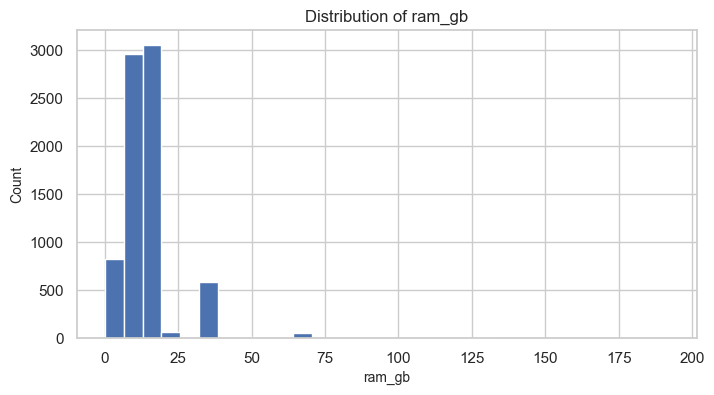

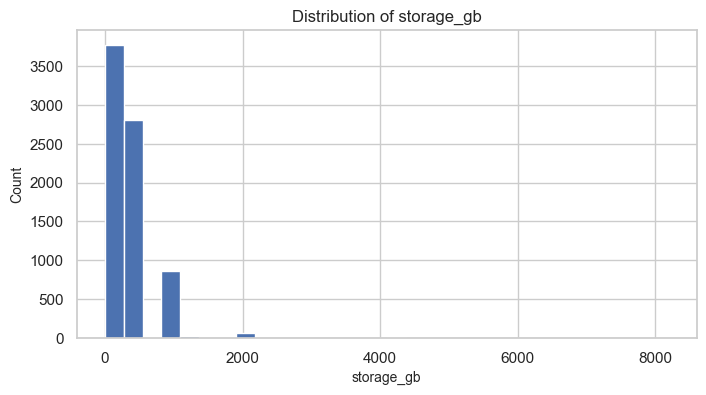

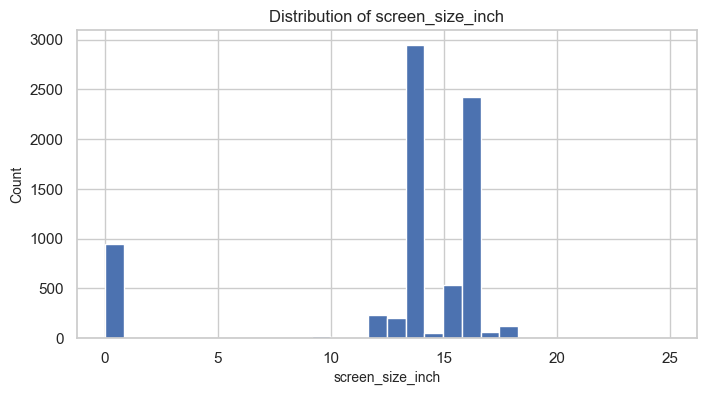

In [232]:
numeric_cols = ["ram_gb", "storage_gb", "screen_size_inch"]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Categorical hóa numeric features theo dạng ordinal

Sau khi quan sát phân phối của ba numeric feature gồm `ram_gb`, `storage_gb` và `screen_size_inch`, có thể thấy các giá trị không phân bố liên tục mà tập trung ở một số mốc phổ biến. Vì vậy, bên cạnh hướng giữ nguyên numeric feature và chuẩn hóa, ta thử thêm hướng rời rạc hóa các numeric feature thành các mức ordinal.

Tuy nhiên, với `ram_gb` và `storage_gb`, các giá trị vẫn có quan hệ thứ tự rõ ràng: RAM lớn hơn hoặc dung lượng lưu trữ lớn hơn thường thể hiện cấu hình cao hơn. Do đó, thay vì chia thành các nhãn rời rạc như `low`, `standard`, `high`, ta mã hóa chúng thành các mức số có thứ tự.

Đối với `ram_gb`, giá trị `0` được giữ là `0`, đại diện cho trường hợp thiếu thông tin. Với các giá trị lớn hơn 0, RAM được chia theo các khoảng lũy thừa của 2. Cụ thể, các giá trị nằm trong khoảng $[2^{i-1}, 2^i]$ sẽ được gán giá trị là `i`. Cách này phù hợp vì RAM laptop thường xuất hiện ở các mức như 4GB, 8GB, 16GB, 32GB và 64GB.

Ví dụ:

```text
0GB  -> 0
4GB  -> 2
8GB  -> 3
16GB -> 4
32GB -> 5
64GB -> 6
```

Đối với `storage_gb`, giá trị 0 được giữ là 0, đại diện cho trường hợp thiếu thông tin. Với các giá trị lớn hơn 0, dung lượng lưu trữ được chia theo các khoảng dựa trên $128 * 2^i$. Cụ thể, các giá trị nằm trong khoảng $[128 * 2^{`i-1}, 128 * 2^i]$ sẽ được gán giá trị là i. Cách này phù hợp vì dung lượng lưu trữ laptop thường xuất hiện ở các mốc như 128GB, 256GB, 512GB, 1TB và 2TB.

Ví dụ:

```
0GB    -> 0
128GB  -> 1
256GB  -> 2
512GB  -> 3
1024GB -> 4
2048GB -> 5
```
Đối với `screen_size_inch`, vì kích thước màn hình không tăng theo cấp số nhân như RAM và storage, ta chia theo các nhóm kích thước phổ biến. Giá trị 0 được giữ là 0, đại diện cho trường hợp thiếu thông tin. Các giá trị còn lại được chia thành các nhóm như màn hình nhỏ, trung bình, tiêu chuẩn và lớn.

Cách mã hóa này giúp biến các numeric feature thành các mức rời rạc nhưng vẫn giữ được quan hệ thứ tự. Vì vậy, các feature mới có thể được sử dụng như ordinal feature trong mô hình.

In [233]:
# Encode numeric features into ordinal levels
def encode_ram_level(x):
    """
    0 -> 0
    [2^(i-1), 2^i] -> i

    Example:
    2GB  -> 1
    4GB  -> 2
    8GB  -> 3
    16GB -> 4
    32GB -> 5
    64GB -> 6
    """
    if pd.isna(x) or x == 0:
        return 0

    x = float(x)
    return int(math.ceil(math.log2(x)))


def encode_storage_level(x):
    if pd.isna(x) or x == 0:
        return 0

    x = float(x)
    if x <= 128:
        return 1

    return int(math.ceil(math.log2(x / 128))) + 1


def encode_screen_size_level(x):
    """
    0 -> 0
    Other values are grouped by common laptop screen sizes.
    """
    if pd.isna(x) or x == 0:
        return 0
    elif x < 14:
        return 1
    elif x < 15.6:
        return 2
    elif x <= 16:
        return 3
    else:
        return 4


df["ram_level"] = df["ram_gb"].apply(encode_ram_level)
df["storage_level"] = df["storage_gb"].apply(encode_storage_level)
df["screen_size_level"] = df["screen_size_inch"].apply(encode_screen_size_level)

In [234]:
level_cols = [
    "ram_level",
    "storage_level",
    "screen_size_level"
]

for col in level_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


ram_level:
ram_level
0     181
1      12
2     602
3    2993
4    3054
5     634
6      77
7      12
8       1
Name: count, dtype: int64

storage_level:
storage_level
0     482
1     727
2    2564
3    2801
4     863
5     113
6      11
7       5
Name: count, dtype: int64

screen_size_level:
screen_size_level
0     950
1    2897
2     633
3    2848
4     238
Name: count, dtype: int64


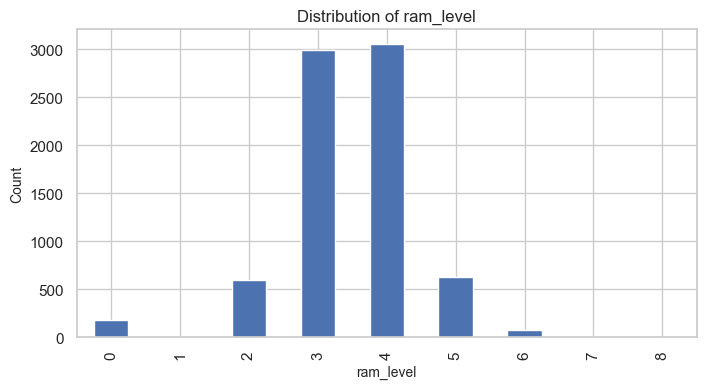

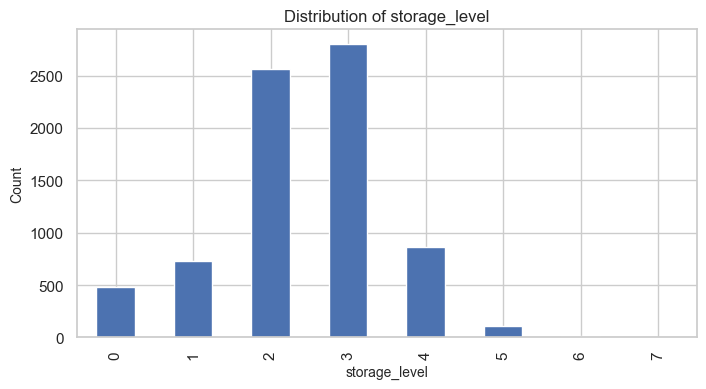

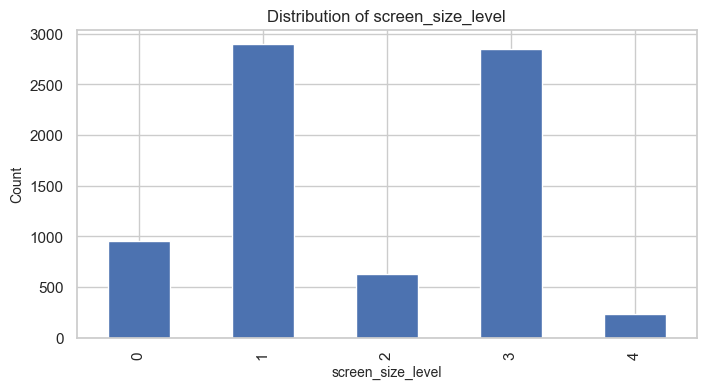

In [235]:
for col in level_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Nhận xét sau khi rời rạc hóa numeric features

Sau khi chuyển ba numeric feature `ram_gb`, `storage_gb` và `screen_size_inch` thành các mức ordinal, có thể thấy các feature mới phản ánh khá rõ các nhóm cấu hình phổ biến của laptop. Các giá trị được mã hóa không còn biểu diễn trực tiếp dung lượng hoặc kích thước gốc, mà biểu diễn cấp độ cấu hình theo thứ tự tăng dần.

Với `ram_level`, dữ liệu tập trung chủ yếu ở level 3 và level 4, tương ứng với các mức RAM phổ biến khoảng 8GB và 16GB. Đây là hai cấu hình RAM xuất hiện nhiều nhất trong tập dữ liệu. Level 5 cũng có số lượng tương đối đáng kể, đại diện cho nhóm RAM khoảng 32GB. Các level cao hơn như 6, 7 và 8 xuất hiện ít hơn, tương ứng với các cấu hình RAM rất cao. Level 0 có 181 dòng, đại diện cho các bản ghi thiếu thông tin RAM đã được fill bằng 0. Nhìn chung, cách mã hóa RAM theo lũy thừa của 2 là phù hợp vì RAM laptop thường tăng theo các mốc 4GB, 8GB, 16GB, 32GB và 64GB.

Với `storage_level`, dữ liệu tập trung chủ yếu ở level 2 và level 3, tương ứng với các mức dung lượng phổ biến khoảng 256GB và 512GB. Level 4, tương ứng với khoảng 1TB, cũng xuất hiện với số lượng đáng kể. Level 1 đại diện cho nhóm dung lượng thấp hơn hoặc bằng 128GB, trong khi level 0 đại diện cho các bản ghi thiếu thông tin storage. Các level cao hơn như 5, 6 và 7 xuất hiện ít hơn, tương ứng với các mức storage rất cao như 2TB, 4TB hoặc cao hơn. Cách mã hóa storage theo các mốc `128 * 2^i` giúp giữ lại các đỉnh quan trọng của phân phối như 128GB, 256GB, 512GB và 1TB, đồng thời tránh tạo ra quá nhiều level lẻ như khi chia tuyến tính theo từng khoảng 128GB.

Với `screen_size_level`, dữ liệu tập trung chủ yếu ở level 1 và level 3. Level 1 tương ứng với nhóm màn hình nhỏ hơn 14 inch, còn level 3 tương ứng với nhóm màn hình phổ biến khoảng 15.6 đến 16 inch. Level 2 có số lượng ít hơn, đại diện cho nhóm màn hình trung bình từ 14 đến dưới 15.6 inch. Level 4 xuất hiện ít nhất, đại diện cho các màn hình lớn hơn 16 inch. Level 0 có 950 dòng, cho thấy số lượng bản ghi thiếu thông tin màn hình tương đối nhiều. Cách chia nhóm màn hình hiện tại phù hợp vì kích thước màn hình laptop thường tập trung quanh một số nhóm phổ biến, thay vì tăng theo cấp số nhân như RAM hoặc storage.

Tóm lại, cách rời rạc hóa này giúp giữ được quan hệ thứ tự của các feature, đồng thời chuyển các giá trị numeric gốc thành các cấp độ cấu hình dễ diễn giải hơn. `ram_level`, `storage_level` và `screen_size_level` đều có phân phối tương đối hợp lý. Đặc biệt, `storage_level` sau khi mã hóa theo mốc lũy thừa của 2 trở nên gọn hơn, giữ được các mức dung lượng phổ biến và giảm bớt các level hiếm không cần thiết. Do đó, các feature dạng level này có thể được sử dụng như ordinal features trong quá trình huấn luyện mô hình.

Ở notebook này, quá trình feature engineering dừng lại ở bước tạo ordinal features. Việc chuẩn hóa bằng MinMaxScaler hoặc các phương pháp scaling khác không được thực hiện tại đây để tránh phụ thuộc vào toàn bộ dữ liệu trước khi chia train/test. Scaling sẽ được xử lý ở bước huấn luyện mô hình, bên trong pipeline tương ứng với từng loại model. Điều này giúp tránh data leakage và cho phép linh hoạt lựa chọn preprocessing phù hợp với từng mô hình.

# 5. Feature Engineering - Categorical Features

In [236]:
for col in cat_cols:
    print(f"\n===== {col} =====")
    
    counts = df[col].value_counts(dropna=False)
    ratios = df[col].value_counts(normalize=True, dropna=False).round(4)
    
    summary = pd.DataFrame({
        "count": counts,
        "ratio": ratios
    })
    
    print(summary)


===== brand_grouped =====
               count  ratio
brand_grouped              
Dell            2117  0.280
Lenovo          1104  0.146
Apple           1023  0.135
HP               962  0.127
ASUS             893  0.118
Acer             496  0.066
Other            401  0.053
MSI              320  0.042
Microsoft        250  0.033

===== model_grouped =====
                count  ratio
model_grouped               
Other            5706  0.754
Latitude          462  0.061
MacBook Pro       318  0.042
Precision         195  0.026
MacBook Air       179  0.024
Inspiron          159  0.021
ThinkPad          106  0.014
Elitebook          95  0.013
Nitro 5            89  0.012
ProBook            89  0.012
MacBook Pro M1     86  0.011
MacBook Air M1     82  0.011

===== cpu_brand =====
              count  ratio
cpu_brand                 
Intel          5930  0.784
AMD             788  0.104
Apple           533  0.070
Other           288  0.038
Qualcomm         25  0.003
Microsoft SQ      2 

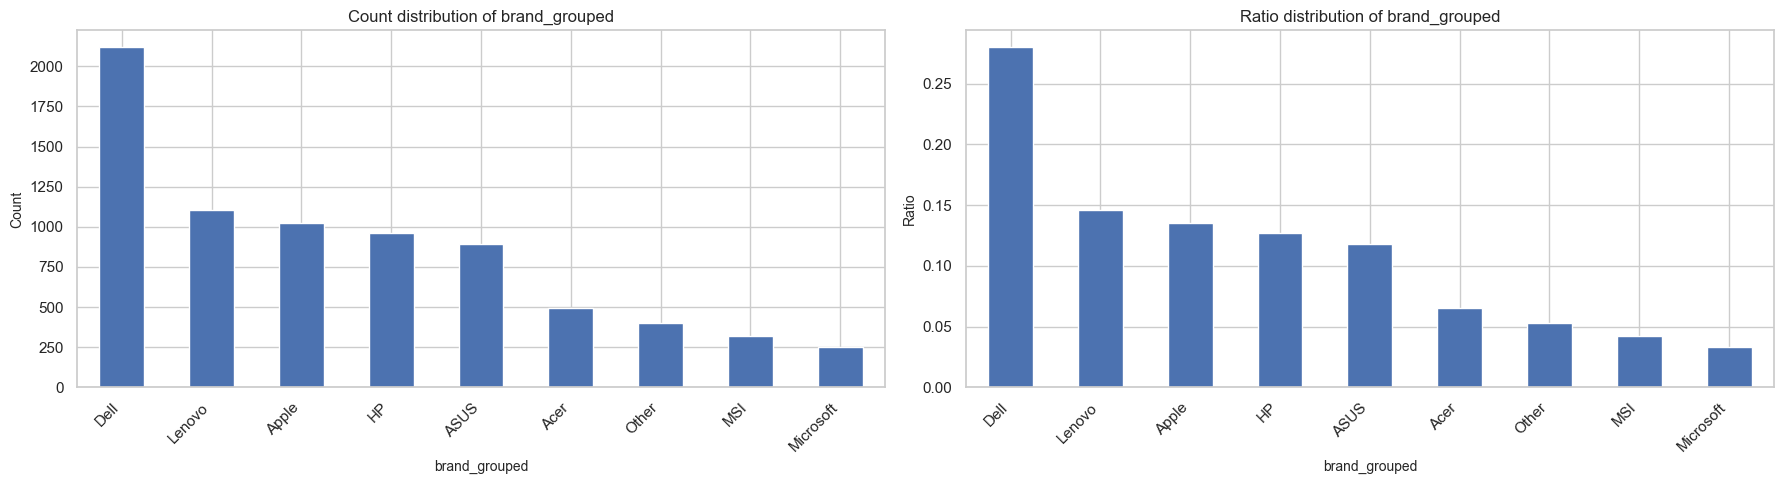

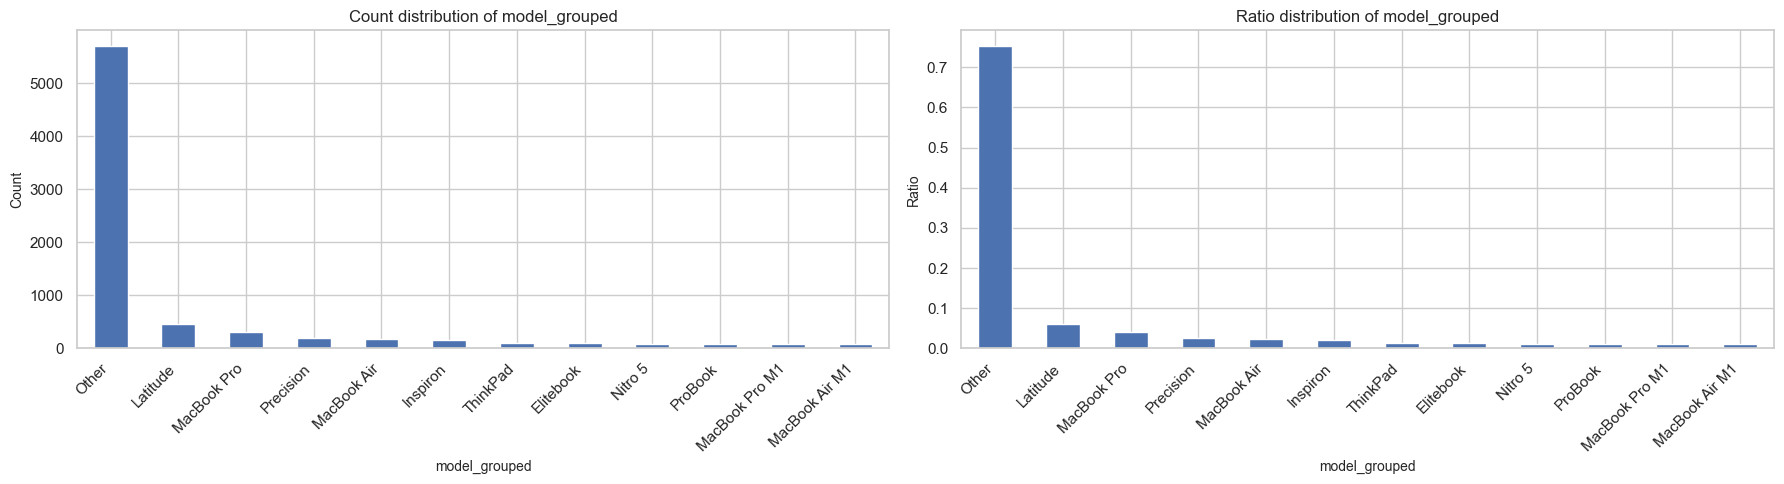

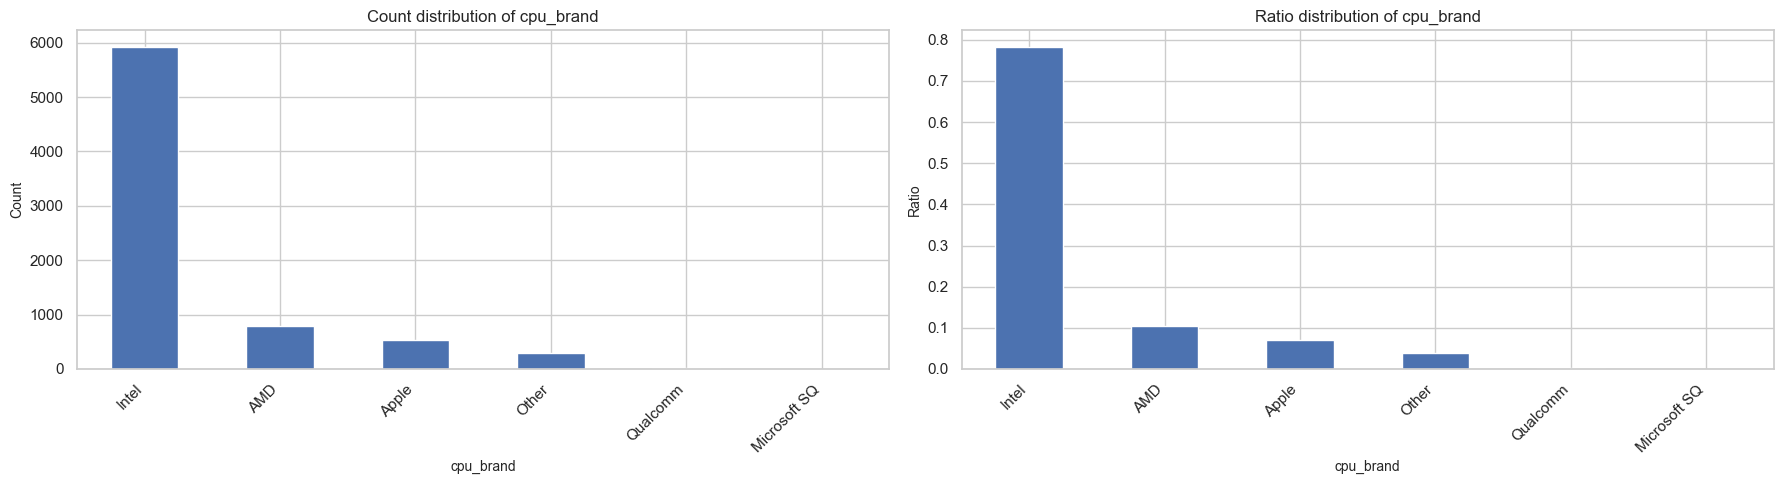

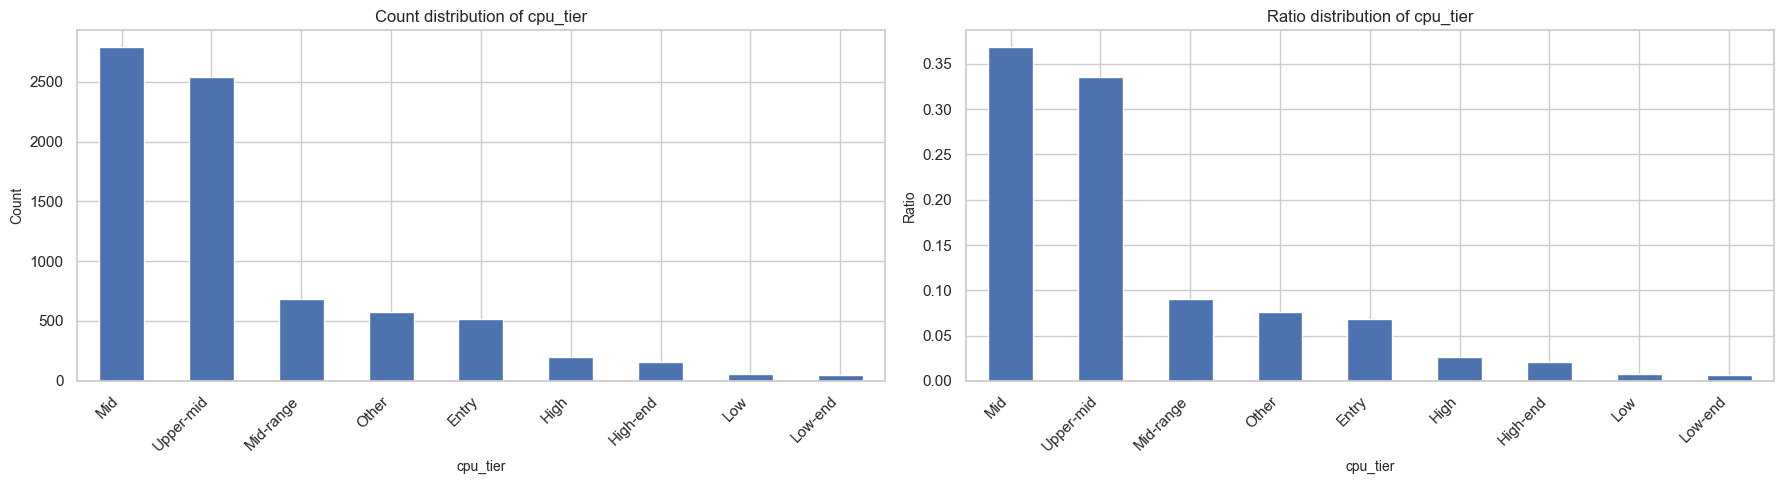

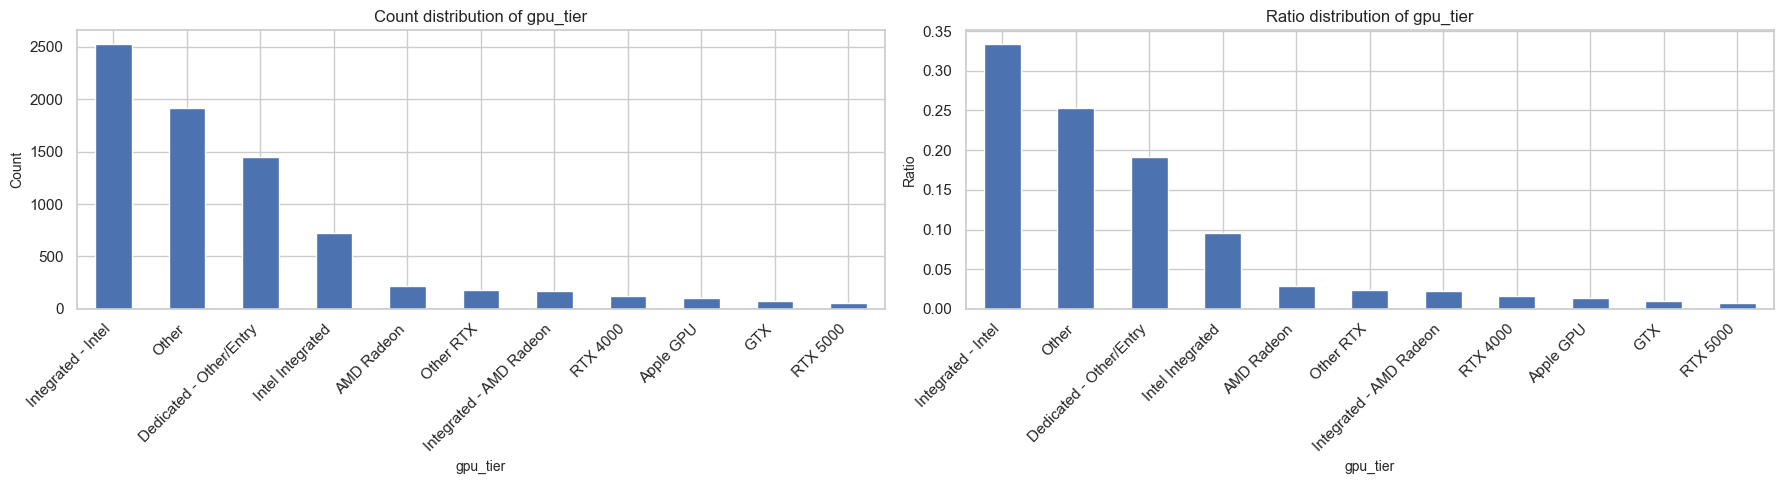

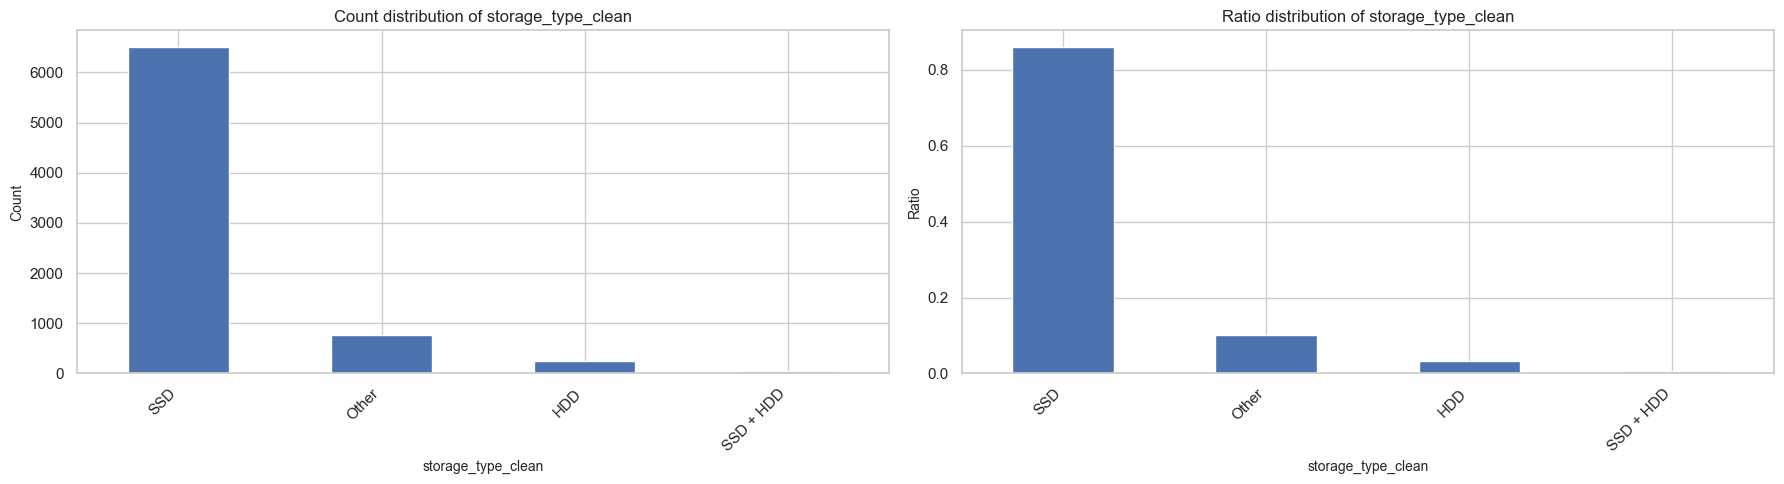

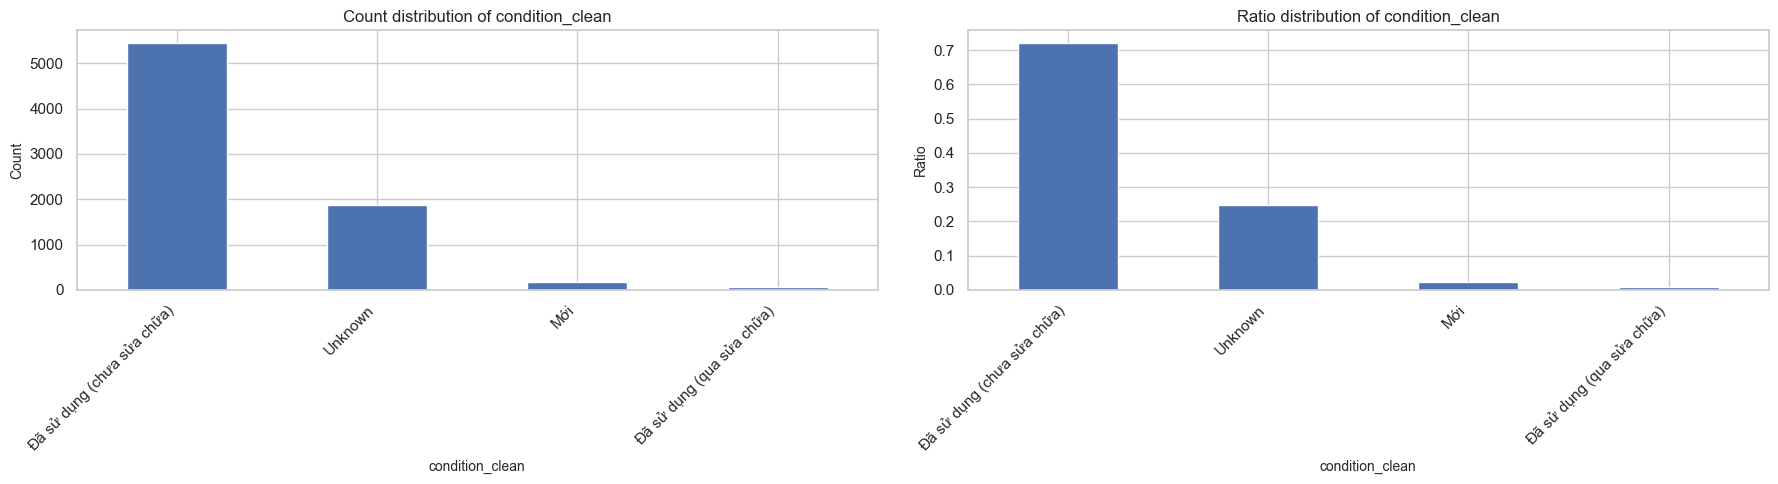

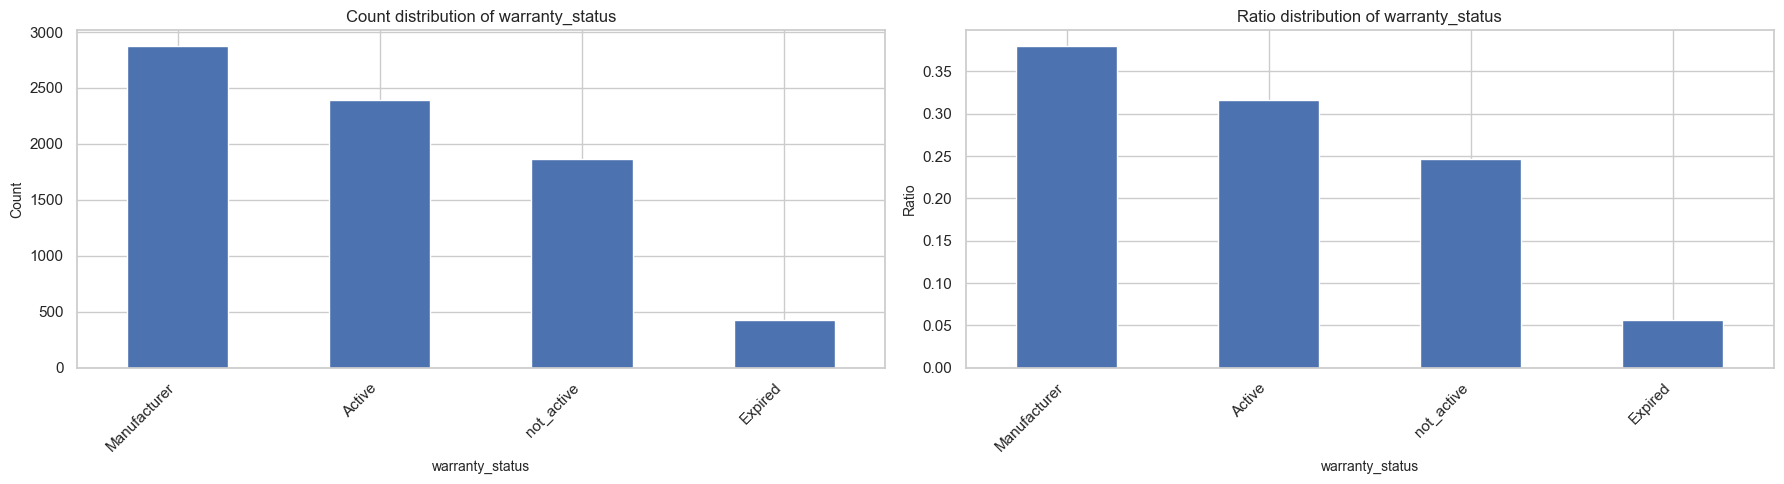

In [237]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    count_data = df[col].value_counts(dropna=False).head(15)
    ratio_data = df[col].value_counts(normalize=True, dropna=False).head(15)

    count_data.plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Count distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    ratio_data.plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Ratio distribution of {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Ratio")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
        for label in ax.get_xticklabels():
            label.set_ha("right")

    plt.tight_layout()
    plt.show()

<Figure size 1200x500 with 0 Axes>

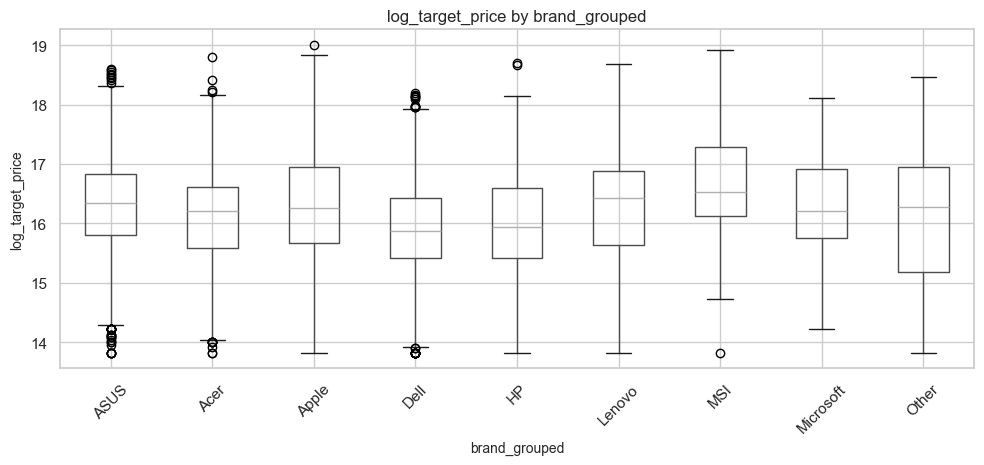

<Figure size 1200x500 with 0 Axes>

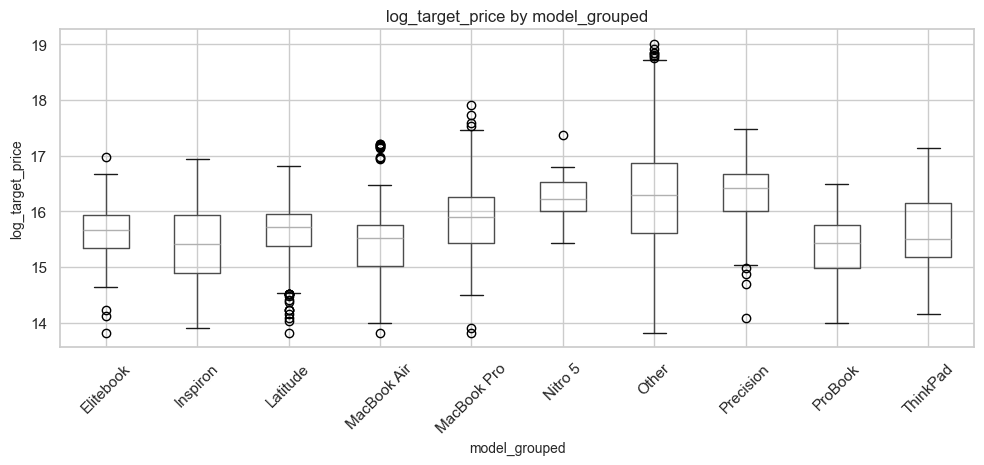

<Figure size 1200x500 with 0 Axes>

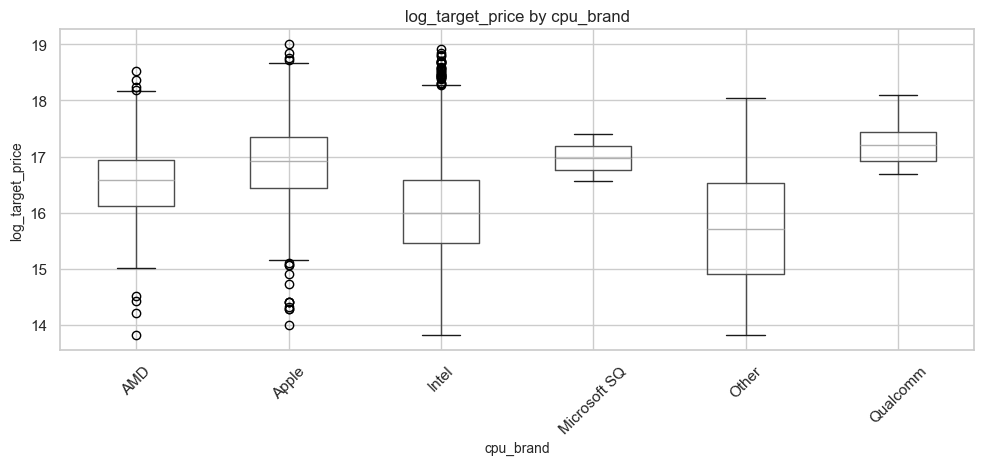

<Figure size 1200x500 with 0 Axes>

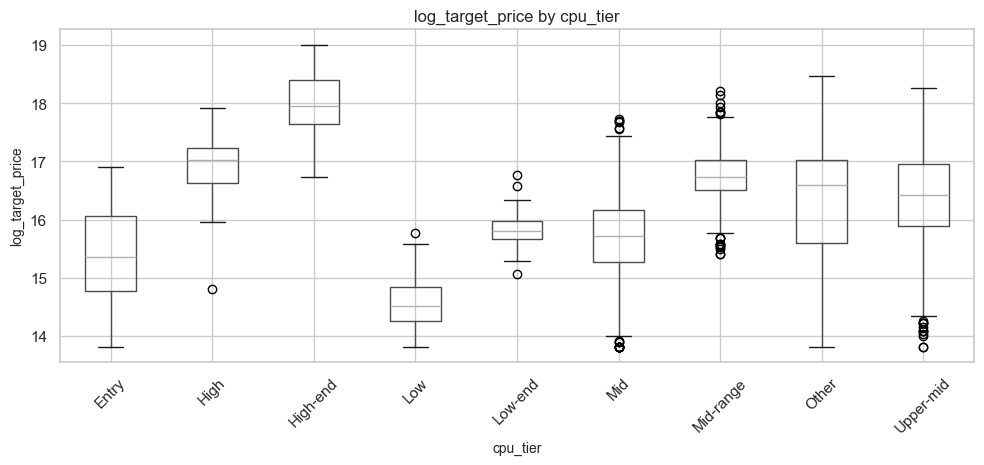

<Figure size 1200x500 with 0 Axes>

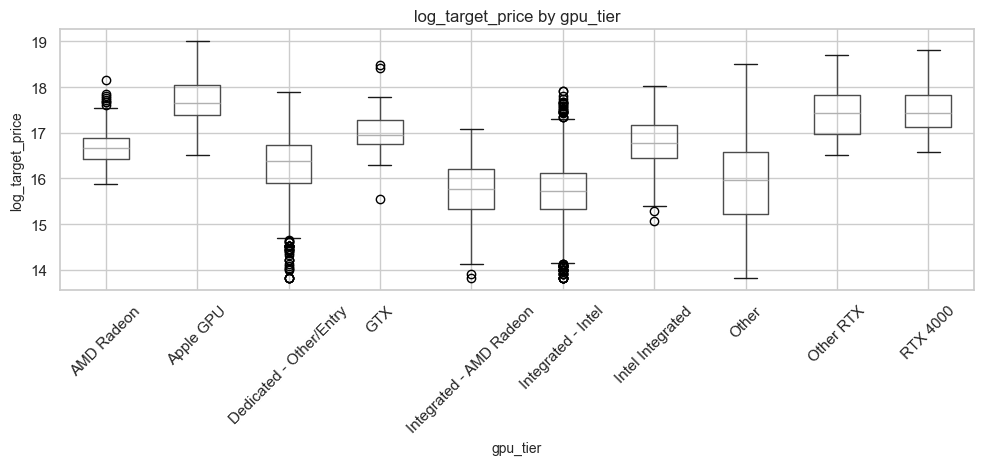

<Figure size 1200x500 with 0 Axes>

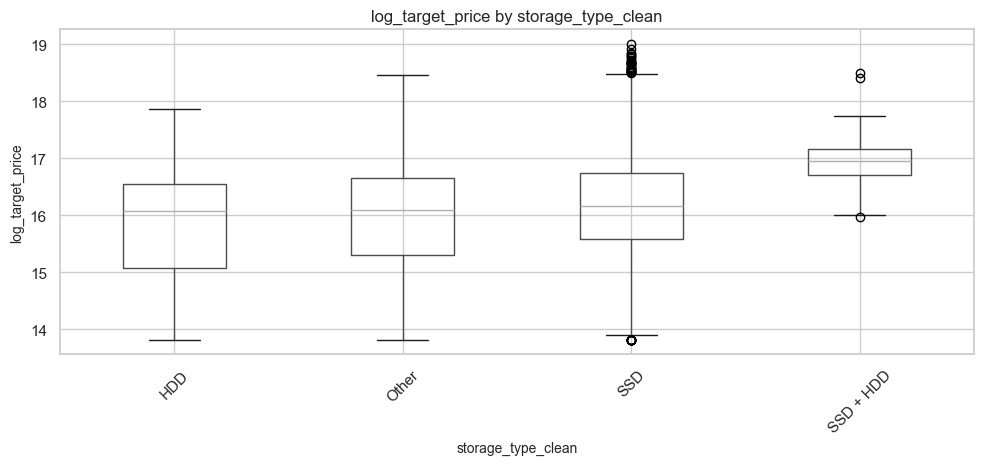

<Figure size 1200x500 with 0 Axes>

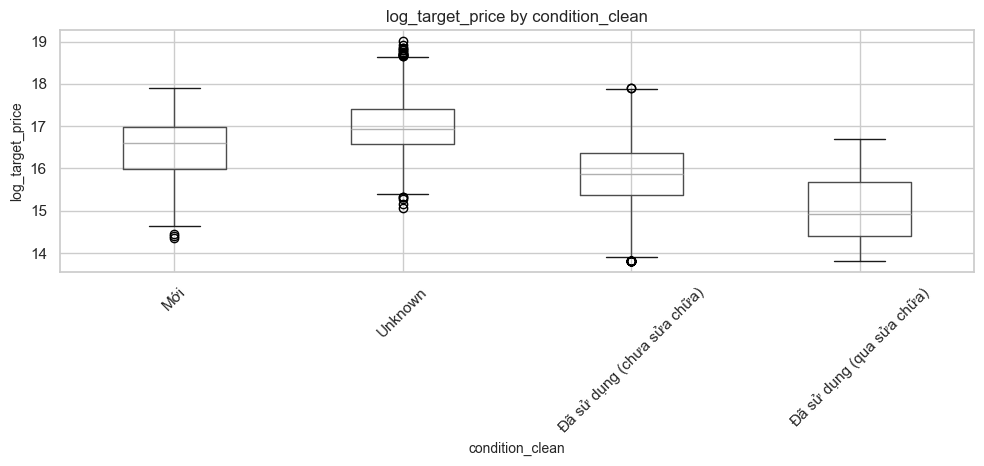

<Figure size 1200x500 with 0 Axes>

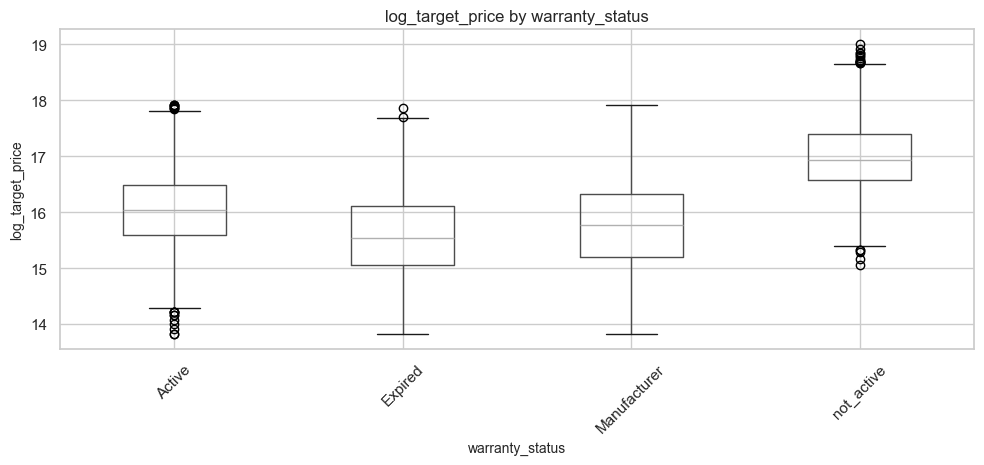

In [238]:
for col in cat_cols:
    top_categories = df[col].value_counts().head(10).index
    temp = df[df[col].isin(top_categories)]

    plt.figure(figsize=(12, 5))
    temp.boxplot(column="log_target_price", by=col, rot=45)
    plt.title(f"log_target_price by {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel("log_target_price")
    plt.tight_layout()
    plt.show()

,feature,rare_category_count,rare_total_ratio
3,cpu_tier,2,0.014
6,condition_clean,1,0.008
4,gpu_tier,1,0.008
5,storage_type_clean,1,0.005
2,cpu_brand,2,0.004
0,brand_grouped,0,0.000
1,model_grouped,0,0.000
7,warranty_status,0,0.000


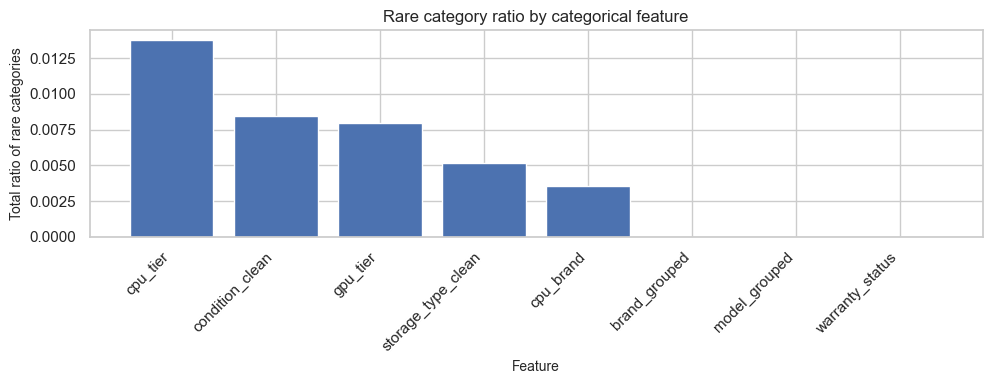

In [239]:
rare_summary = []

for col in cat_cols:
    freq = df[col].value_counts(normalize=True, dropna=False)
    rare_ratio = freq[freq < 0.01].sum()
    rare_count = (freq < 0.01).sum()

    rare_summary.append({
        "feature": col,
        "rare_category_count": rare_count,
        "rare_total_ratio": rare_ratio
    })

rare_summary = pd.DataFrame(rare_summary).sort_values("rare_total_ratio", ascending=False)
display(rare_summary)

plt.figure(figsize=(10, 4))
plt.bar(rare_summary["feature"], rare_summary["rare_total_ratio"])
plt.title("Rare category ratio by categorical feature")
plt.xlabel("Feature")
plt.ylabel("Total ratio of rare categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Phân tích rare category cho thấy hầu hết các biến categorical có tỷ lệ nhóm hiếm khá thấp. 
Biến `model_grouped` có tỷ lệ rare category cao nhất, khoảng 11.4%, với 20 category hiếm. 
Điều này cho thấy tên model laptop khá đa dạng và phân tán, vì vậy việc gom các model hiếm vào nhóm "Other" là cần thiết để giảm nhiễu và tránh overfitting.

Các biến còn lại như `cpu_tier`, `brand_grouped`, `condition_clean`, `gpu_tier`, `storage_type_clean`, và `cpu_brand` đều có tỷ lệ rare category thấp, dưới 1.5%. 
Riêng `warranty_status` không có rare category, cho thấy các nhóm trong biến này được phân bố khá ổn định.

Chúng ta sẽ bắt đầu encoding với 1 số feature đơn giản trước.

In [240]:
# SSD       → storage_ssd=1, storage_hdd=0, no_info_storage=0
# HDD       → storage_ssd=0, storage_hdd=1, no_info_storage=0
# SSD + HDD → storage_ssd=1, storage_hdd=1, no_info_storage=0
# Other     → storage_ssd=0, storage_hdd=0, no_info_storage=1

df["storage_ssd"] = df["storage_type_clean"].isin(["SSD", "SSD + HDD"]).astype(int)
df["storage_hdd"] = df["storage_type_clean"].isin(["HDD", "SSD + HDD"]).astype(int)
df["no_info_storage"] = df["storage_type_clean"].eq("Other").astype(int)

In [241]:
condition_map = {
    "Đã sử dụng (qua sửa chữa)": 1,
    "Đã sử dụng (chưa sửa chữa)": 2,
    "Mới": 3
}

df["no_info_condition"] = df["condition_clean"].eq("Unknown").astype(int)
df["condition_score"] = df["condition_clean"].map(condition_map)
df["condition_score"] = df["condition_score"].fillna(2)

In [242]:
warranty_map = {
    "Expired": 0,
    "Active": 1,
    "Manufacturer": 1,
    "not_active": 2
}

df["warranty_encoded"] = df["warranty_status"].map(warranty_map)

## Encode Brand, Model và CPU

Trước khi đưa dữ liệu vào mô hình, các cột dạng chữ cần được chuyển sang dạng số. Trong phần này, các cột được xử lý gồm `brand_grouped`, `model_grouped`, `cpu_brand` và `cpu_tier`.

### Brand

Cột `brand_grouped` thể hiện thương hiệu laptop như Dell, Lenovo, Apple, HP, ASUS hoặc Other. Đây là biến phân loại không có thứ tự, vì vậy nên sử dụng One-Hot Encoding. Cách này giúp mỗi thương hiệu được biểu diễn thành một cột riêng, tránh việc mô hình hiểu nhầm rằng các hãng có quan hệ lớn nhỏ với nhau.

### Model

Cột `model_grouped` thể hiện dòng máy hoặc model laptop như Latitude, MacBook Pro, ThinkPad, Inspiron hoặc Other. Cột này cũng là biến phân loại không có thứ tự, nên phù hợp với One-Hot Encoding. Việc encode giúp mô hình nhận biết từng nhóm model mà không tạo ra thứ tự giả giữa các model.

### CPU Brand

Cột `cpu_brand` thể hiện hãng CPU như Intel, AMD, Apple, Qualcomm, Microsoft SQ hoặc Other. Đây cũng là biến phân loại không có thứ tự, nên sử dụng One-Hot Encoding. Như vậy, mỗi hãng CPU sẽ được tách thành một đặc trưng riêng để mô hình xử lý tốt hơn.

### CPU Tier

Cột `cpu_tier` thể hiện phân khúc hiệu năng của CPU, ví dụ Low-end, Low, Entry, Mid-range, Mid, Upper-mid, High và High-end. Khác với brand và model, cột này có thứ tự từ thấp đến cao, nên có thể sử dụng Ordinal Encoding. Các mức CPU sẽ được chuyển thành số theo thứ tự hiệu năng tăng dần.

In [243]:
# Encode cpu_tier bằng Ordinal Encoding
cpu_tier_map = {
    "Other": 0,
    "Low-end": 1,
    "Low": 2,
    "Entry": 3,
    "Mid-range": 4,
    "Mid": 5,
    "Upper-mid": 6,
    "High": 7,
    "High-end": 8
}

df["cpu_tier_encoded"] = df["cpu_tier"].map(cpu_tier_map)

# Kiểm tra giá trị cpu_tier chưa được map
print("Các giá trị cpu_tier chưa được map:")
print(df[df["cpu_tier_encoded"].isna()]["cpu_tier"].unique())

# One-Hot Encoding cho các biến không có thứ tự
onehot_cols = [
    "brand_grouped",
    "model_grouped",
    "cpu_brand"
]

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    prefix=["brand", "model", "cpu_brand"],
    dtype=int
)

Các giá trị cpu_tier chưa được map:
[]


## Encode GPU features

Cột `gpu_tier` ban đầu không nên được encode trực tiếp vì nó đang trộn nhiều loại thông tin khác nhau, bao gồm loại GPU và mức hiệu năng. Do đó, cần tách cột này thành các feature rõ nghĩa hơn trước khi đưa vào model.

Sau khi kiểm tra correlation heatmap, việc tạo quá nhiều feature từ GPU có thể gây dư thừa thông tin. Vì vậy, thay vì giữ cả `gpu_type`, `gpu_vendor` và nhiều missing indicators, ta sử dụng phiên bản rút gọn hơn.

### Cách xử lý

Từ cột `gpu_tier`, tạo ra các feature mới:

- `gpu_type`: thể hiện loại GPU, ví dụ `Integrated`, `Dedicated`, `Apple SoC`, `Missing_Info`
- `gpu_tier_clean`: thể hiện tier hiệu năng đã được chuẩn hóa
- `gpu_tier_ord`: phiên bản ordinal encoding của `gpu_tier_clean`

Trong đó, `gpu_vendor` không được giữ trong bộ feature cuối cùng vì thông tin này có thể bị chồng lặp với `gpu_type`.

### Ý nghĩa của missing GPU

Cột `no_info_gpu` được dùng để xác định các dòng thiếu thông tin GPU.

Trong data hiện tại, các giá trị như `Other`, missing value, hoặc các nhóm không đủ rõ để xác định GPU sẽ được xem là thiếu thông tin GPU. Những dòng này được gộp vào nhóm `Missing_Info`.

Với các dòng thiếu thông tin GPU:

- đặt `gpu_type` là `Missing_Info`
- đặt `gpu_tier_clean` là missing hoặc `Unknown`
- đặt `gpu_tier_ord_filled = -1`

Cách này giúp model nhận biết rằng dòng đó thiếu thông tin GPU, thay vì hiểu nhầm nó là một mức hiệu năng thấp hơn `Integrated`.

### Nguyên tắc encode

`gpu_type` là biến categorical nominal, không có thứ tự tự nhiên. Vì vậy, biến này được encode bằng one-hot encoding.

`gpu_tier_clean` là biến có thứ tự hiệu năng, nên được encode bằng ordinal encoding. Thứ tự đề xuất là:

- `Integrated`: 0
- `Entry`: 1
- `Mid_High`: 2
- `High_Workstation`: 3
- `Very_High_Workstation`: 4

Với các dòng thiếu thông tin GPU, giá trị ordinal được fill bằng `-1`.

### Feature cuối cùng nên dùng

Bộ feature GPU cuối cùng gồm:

- `gpu_tier_ord_filled`
- các cột one-hot từ `gpu_type`

Nếu dùng `drop_first=True`, một nhóm trong `gpu_type` sẽ được dùng làm baseline. Do đó, bộ feature cuối cùng có thể gồm:

- `gpu_tier_ord_filled`
- `gpu_type_Dedicated`
- `gpu_type_Integrated`
- `gpu_type_Missing_Info`

Nhóm còn lại, ví dụ `Apple SoC`, sẽ đóng vai trò baseline và không cần tạo cột riêng.

### Lý do rút gọn feature

Correlation heatmap cho thấy một số GPU-derived features có tương quan cao với nhau. Điều này cho thấy các feature này có thể chứa thông tin chồng lặp.

Việc rút gọn bộ GPU features giúp:

- giảm số chiều dữ liệu
- giảm thông tin dư thừa
- hạn chế multicollinearity
- giữ lại các tín hiệu quan trọng nhất về GPU

### Kết luận

Không nên ordinal encode trực tiếp cột `gpu_tier` gốc. Cách xử lý phù hợp hơn là:

- tách `gpu_tier` thành `gpu_type` và `gpu_tier_clean`
- `gpu_type`: one-hot encoding
- `gpu_tier_clean`: ordinal encoding
- `Other`, missing value và các giá trị không đủ rõ: gộp chung thành `Missing_Info`
- không giữ `gpu_vendor` trong bộ feature cuối cùng vì có thể bị chồng lặp thông tin với `gpu_type`

Cách biểu diễn cuối cùng giúp giữ lại thông tin quan trọng của GPU nhưng vẫn đơn giản và ít dư thừa hơn.

In [244]:

# 1. Chuẩn hóa text
df["gpu_raw"] = df["gpu_tier"].astype("string").str.strip()

# 2. Missing flag
df["gpu_missing"] = (
    df["gpu_raw"].eq("Other")
    | df["gpu_raw"].isna()
    | df["no_info_gpu"].astype(bool)
).astype(int)

# 3. Tạo gpu_type
type_map = {
    "Integrated - Intel": "Integrated",
    "Intel Integrated": "Integrated",
    "Integrated - AMD Radeon": "Integrated",

    "Dedicated - Other/Entry": "Dedicated",
    "GTX": "Dedicated",
    "Other RTX": "Dedicated",
    "RTX 4000": "Dedicated",
    "RTX 5000": "Dedicated",

    "Apple GPU": "Apple SoC",

    "AMD Radeon": "Missing_Info",
    "Other": "Missing_Info",
}

df["gpu_type"] = df["gpu_raw"].map(type_map).fillna("Missing_Info")
df.loc[df["gpu_missing"].eq(1), "gpu_type"] = "Missing_Info"

# 4. Tạo gpu_tier_clean
tier_map = {
    "Integrated - Intel": "Integrated",
    "Intel Integrated": "Integrated",
    "Integrated - AMD Radeon": "Integrated",

    "Dedicated - Other/Entry": "Entry",
    "GTX": "Entry",
    "Other RTX": "Mid_High",
    "RTX 4000": "High_Workstation",
    "RTX 5000": "Very_High_Workstation",

    # FIX: Apple GPU không để NaN nữa
    "Apple GPU": "Apple_SoC",

    # Missing / không rõ
    "AMD Radeon": "Unknown",
    "Other": "Unknown",
}

df["gpu_tier_clean"] = df["gpu_raw"].map(tier_map).fillna("Unknown")
df.loc[df["gpu_missing"].eq(1), "gpu_tier_clean"] = "Unknown"

# 5. Ordinal encode tier
gpu_tier_ord_map = {
    "Unknown": -1,
    "Integrated": 0,
    "Apple_SoC": 1,
    "Entry": 2,
    "Mid_High": 3,
    "High_Workstation": 4,
    "Very_High_Workstation": 5,
}

df["gpu_tier_ord_filled"] = (
    df["gpu_tier_clean"]
      .map(gpu_tier_ord_map)
      .fillna(-1)
      .astype(int)
)

# 6. One-hot encode gpu_type ngay trong df
gpu_type_dummies = pd.get_dummies(
    df["gpu_type"],
    prefix="gpu_type",
    drop_first=True,
    dtype=int
)

df = pd.concat([df, gpu_type_dummies], axis=1)

# 7. GPU features cuối cùng
gpu_feature_cols = [
    "gpu_tier_ord_filled",
    "gpu_missing",
] + [
    col for col in df.columns
    if col.startswith("gpu_type_")
]

print(gpu_feature_cols)

# 8. Check nhanh
print("\nNaN trong gpu_tier_ord_filled:", df["gpu_tier_ord_filled"].isna().sum())

print("\ngpu_tier_clean:")
print(df["gpu_tier_clean"].value_counts(dropna=False))

print("\ngpu_type:")
print(df["gpu_type"].value_counts(dropna=False))

['gpu_tier_ord_filled', 'gpu_missing', 'gpu_type_Dedicated', 'gpu_type_Integrated', 'gpu_type_Missing_Info']

NaN trong gpu_tier_ord_filled: 0

gpu_tier_clean:
gpu_tier_clean
Integrated               3431
Unknown                  2132
Entry                    1526
Mid_High                  183
High_Workstation          127
Apple_SoC                 107
Very_High_Workstation      60
Name: count, dtype: int64

gpu_type:
gpu_type
Integrated      3431
Missing_Info    2132
Dedicated       1896
Apple SoC        107
Name: count, dtype: int64


In [245]:
df = df.drop(columns=[
    c for c in [
        "gpu_raw",
        "gpu_type",
        "gpu_tier_clean",
        "no_info_gpu",
    ]
    if c in df.columns
])

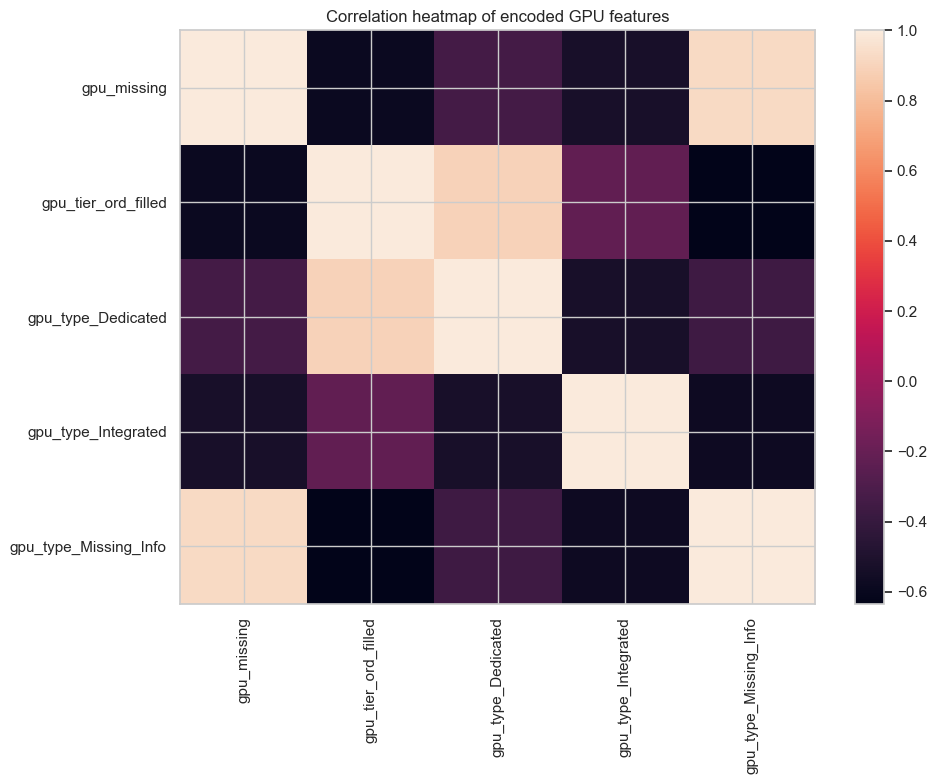

In [246]:
gpu_encoded_cols = [
    col for col in df.columns
    if col.startswith("gpu_type_")
    or col in ["gpu_tier_ord_filled", "gpu_missing"]
]

corr = df[gpu_encoded_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap of encoded GPU features")
plt.tight_layout()
plt.show()

Heatmap tương quan cho thấy mối quan hệ giữa các GPU features sau khi encode.

`gpu_tier_ord_filled` có tương quan dương với `gpu_type_Dedicated`, điều này hợp lý vì GPU rời thường đại diện cho mức hiệu năng cao hơn. Ngược lại, `gpu_tier_ord_filled` có tương quan âm với `gpu_type_Missing_Info`, vì các dòng thiếu thông tin GPU được mã hóa bằng một giá trị riêng.

Các biến one-hot của GPU type, bao gồm `gpu_type_Dedicated`, `gpu_type_Integrated`, và `gpu_type_Missing_Info`, có tương quan âm với nhau. Đây là điều bình thường vì các nhóm GPU type là các nhóm loại trừ lẫn nhau: mỗi laptop chỉ thuộc một nhóm GPU type.

Nhìn chung, các GPU features sau khi encode là hợp lý và dễ diễn giải. Bộ feature này thể hiện được cả mức hiệu năng GPU và loại GPU mà không làm mô hình trở nên phức tạp không cần thiết.

# 6. Review and Save

In [247]:
print(f"Data encode shape: {df.shape}")
print(df.columns.tolist())
display(df.dtypes.to_frame("dtype"))

Data encode shape: (7566, 61)
['ram_gb', 'storage_gb', 'screen_size_inch', 'cpu_tier', 'gpu_tier', 'storage_type_clean', 'condition_clean', 'warranty_status', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'target_price', 'log_target_price', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'ram_level', 'storage_level', 'screen_size_level', 'storage_ssd', 'storage_hdd', 'no_info_storage', 'no_info_condition', 'condition_score', 'warranty_encoded', 'cpu_tier_encoded', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_HP', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'model_Elitebook', 'model_Inspiron', 'model_Latitude', 'model_MacBook Air', 'model_MacBook Air M1', 'model_MacBook Pro', 'model_MacBook Pro M1', 'model_Nitro 5', 'model_Other', 'model_Precision', 'model_ProBook', 'model_ThinkPad', 'cpu_brand_AMD', 'cpu_brand_Apple', 'cpu_brand_Intel', 'cpu_brand_Microsoft SQ', 'cpu_brand_Other', '

,dtype
ram_gb,float64
storage_gb,float64
screen_size_inch,float64
cpu_tier,object
gpu_tier,object
storage_type_clean,object
condition_clean,object
warranty_status,object
brand_is_rare,int32
model_is_rare,int32


In [248]:
drop_before_save = [
    "cpu_tier",
    "gpu_tier",
    "storage_type_clean",
    "condition_clean",
    "warranty_status",
]

df = df.drop(columns=[c for c in drop_before_save if c in df.columns])

In [249]:
print("Shape:", df.shape)

print("\nObject columns còn lại:")
print(df.select_dtypes(include=["object", "category", "string"]).columns.tolist())

print("\nMissing values còn lại:")
missing_after = df.isna().sum()
print(missing_after[missing_after > 0])

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nGPU cols:")
print([c for c in df.columns if c.startswith("gpu_")])

print("\nTarget columns:")
print([c for c in ["target_price", "log_target_price"] if c in df.columns])

Shape: (7566, 56)

Object columns còn lại:
[]

Missing values còn lại:
Series([], dtype: int64)

Duplicate rows:
370

GPU cols:
['gpu_missing', 'gpu_tier_ord_filled', 'gpu_type_Dedicated', 'gpu_type_Integrated', 'gpu_type_Missing_Info']

Target columns:
['target_price', 'log_target_price']


In [250]:
print("Duplicate rows trước khi xóa:", df.duplicated().sum())

df = df.drop_duplicates().copy()

print("Duplicate rows sau khi xóa:", df.duplicated().sum())
print("Shape sau khi xóa duplicate rows:", df.shape)

Duplicate rows trước khi xóa: 370
Duplicate rows sau khi xóa: 0
Shape sau khi xóa duplicate rows: (7196, 56)


In [251]:
df.to_csv(PROCESSED_PATH, index=False)

print("Saved to:", PROCESSED_PATH)
print("Final shape:", df.shape)

Saved to: y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
Final shape: (7196, 56)
